In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [2]:
import src.preference_factors.build_datasets as bd


In [3]:
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_daily_with_tickers.csv",
    market_caps_file="sp500_market_caps_daily.csv",
    ff_factors_file="ff_factors_daily.csv",
    frequency="daily"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


Rolling OLS CAPM:   0%|          | 0/15229 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/15229 [00:00<?, ?it/s]

In [4]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

In [5]:
asset_returns = bd.build_returns_dataset("sp500_returns_daily_with_tickers.csv", frequency="daily")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=252, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=252, min_obs=10)


Estimating rolling betas: 100%|██████████| 14977/14977 [13:18<00:00, 18.75it/s]


In [6]:
results = run_full_factor_pipeline(
    beta1_df=betas_ebc,
    beta2_df=betas_cw_ebc,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'daily'
)

results["mean_grid"]

forming portfolios: 100%|██████████| 14977/14977 [01:29<00:00, 167.73it/s]


,1,2,3
1,0.000559,0.000639,0.000689
2,0.000487,0.000532,0.000580
3,0.000438,0.000488,0.000509


In [7]:
results["portrets_wide"][:5]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1965-07-01,0.006284,0.011163,0.010161,0.005136,0.004693,0.010093,0.004440,0.004795,0.004814
1965-07-02,0.011181,0.009357,0.012044,0.005551,0.008383,0.005737,0.008087,0.005980,0.005173
1965-07-06,-0.003283,-0.003886,-0.002492,-0.003261,0.002380,0.003671,0.000396,0.002386,0.002331
1965-07-07,-0.008031,-0.006002,-0.006996,-0.003542,-0.002266,-0.002611,-0.001329,-0.000552,-0.000913
1965-07-08,0.022338,0.013166,0.003573,0.008705,0.009580,0.005492,0.001431,0.001740,0.000857


In [ ]:
results

In [151]:
from pathlib import Path
import importlib
import src.FamaMacBeth.backtest as backtest
importlib.reload(backtest)
'''(
    load_monthly_inputs,
    backtest_quantile_portfolios,
    compute_excess_returns,
)
'''
import src.FamaMacBeth.plots as plots

importlib.reload(plots)
'''(
    plot_cum_log_returns,
    plot_expected_return_grid,
)
'''

'(\n    plot_cum_log_returns,\n    plot_expected_return_grid,\n)\n'

In [175]:
# ============================
# USER PARAMETERS
# ============================
start_date = "1970-01-01"
#start_date = '2000-01-01'
use_excess_returns = True

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = backtest.load_daily_inputs(DATA_RAW_DIR)

In [176]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
    frequency='daily'
)

if use_excess_returns:
    quantile_portfolios_returns = backtest.compute_excess_returns(
        quantile_portfolios_returns, rf, start_date=start_date
    )
else:
    quantile_portfolios_returns = quantile_portfolios_returns.loc[start_date:]

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

In [177]:
quantile_portfolios_returns

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1970-01-02,0.019452,0.019181,0.030032,0.007032,0.010613,0.017388,0.003212,0.012963,0.023283
1970-01-05,0.003037,0.004294,0.013488,0.002868,0.004968,0.014917,0.006287,0.012816,0.015405
1970-01-06,-0.016116,-0.011919,-0.007252,-0.007633,-0.009632,-0.010271,-0.003530,-0.007613,-0.010083
1970-01-07,-0.004923,-0.002467,-0.004585,-0.002359,-0.005077,-0.001224,0.000240,-0.001851,-0.001777
1970-01-08,0.001289,-0.000659,-0.003893,0.002016,-0.001426,-0.001860,-0.000864,-0.000626,0.000016
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640
2024-12-26,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003
2024-12-27,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013


In [178]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


In [179]:
quantile_portfolios_returns

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
date,,,,,,,,,
1970-01-02,0.019452,0.019181,0.030032,0.007032,0.010613,0.017388,0.003212,0.012963,0.023283
1970-01-05,0.003037,0.004294,0.013488,0.002868,0.004968,0.014917,0.006287,0.012816,0.015405
1970-01-06,-0.016116,-0.011919,-0.007252,-0.007633,-0.009632,-0.010271,-0.003530,-0.007613,-0.010083
1970-01-07,-0.004923,-0.002467,-0.004585,-0.002359,-0.005077,-0.001224,0.000240,-0.001851,-0.001777
1970-01-08,0.001289,-0.000659,-0.003893,0.002016,-0.001426,-0.001860,-0.000864,-0.000626,0.000016
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640
2024-12-26,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003
2024-12-27,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013


In [180]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [181]:
complete_df['CW-RF'] = complete_df['CW'] - complete_df['RF']


In [182]:
complete_df

,CW,EW,EBC,CW-EW,CW-EBC,MKT_RF,SMB,HML,RMW,CMA,...,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low,CW-RF
date,,,,,,,,,,,,,,,,,,,,,
1970-01-02,0.010678,0.019777,0.017760,-0.009098,-0.007081,0.0118,0.0137,0.0104,-0.0117,0.0045,...,0.019452,0.019181,0.030032,0.007032,0.010613,0.017388,0.003212,0.012963,0.023283,0.010378
1970-01-05,0.005356,0.010711,0.011853,-0.005356,-0.006498,0.0059,0.0076,0.0074,-0.0052,0.0074,...,0.003037,0.004294,0.013488,0.002868,0.004968,0.014917,0.006287,0.012816,0.015405,0.005056
1970-01-06,-0.006900,-0.007389,-0.006587,0.000488,-0.000313,-0.0074,0.0006,0.0021,-0.0005,0.0031,...,-0.016116,-0.011919,-0.007252,-0.007633,-0.009632,-0.010271,-0.003530,-0.007613,-0.010083,-0.007200
1970-01-07,-0.001775,-0.001366,-0.001642,-0.000410,-0.000134,-0.0015,0.0041,-0.0034,0.0021,-0.0042,...,-0.004923,-0.002467,-0.004585,-0.002359,-0.005077,-0.001224,0.000240,-0.001851,-0.001777,-0.002075
1970-01-08,0.000586,-0.000056,0.000277,0.000642,0.000309,0.0003,0.0019,-0.0017,-0.0004,-0.0029,...,0.001289,-0.000659,-0.003893,0.002016,-0.001426,-0.001860,-0.000864,-0.000626,0.000016,0.000286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011481,0.007806,0.007682,0.003675,0.003798,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,...,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640,0.011281
2024-12-26,-0.000346,0.001047,0.001133,-0.001393,-0.001479,0.0001,0.0107,-0.0018,-0.0042,0.0036,...,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003,-0.000546
2024-12-27,-0.011024,-0.007075,-0.006283,-0.003949,-0.004741,-0.0117,-0.0044,0.0057,0.0039,0.0004,...,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013,-0.011224


In [183]:
selected_columns = ['CW-RF','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

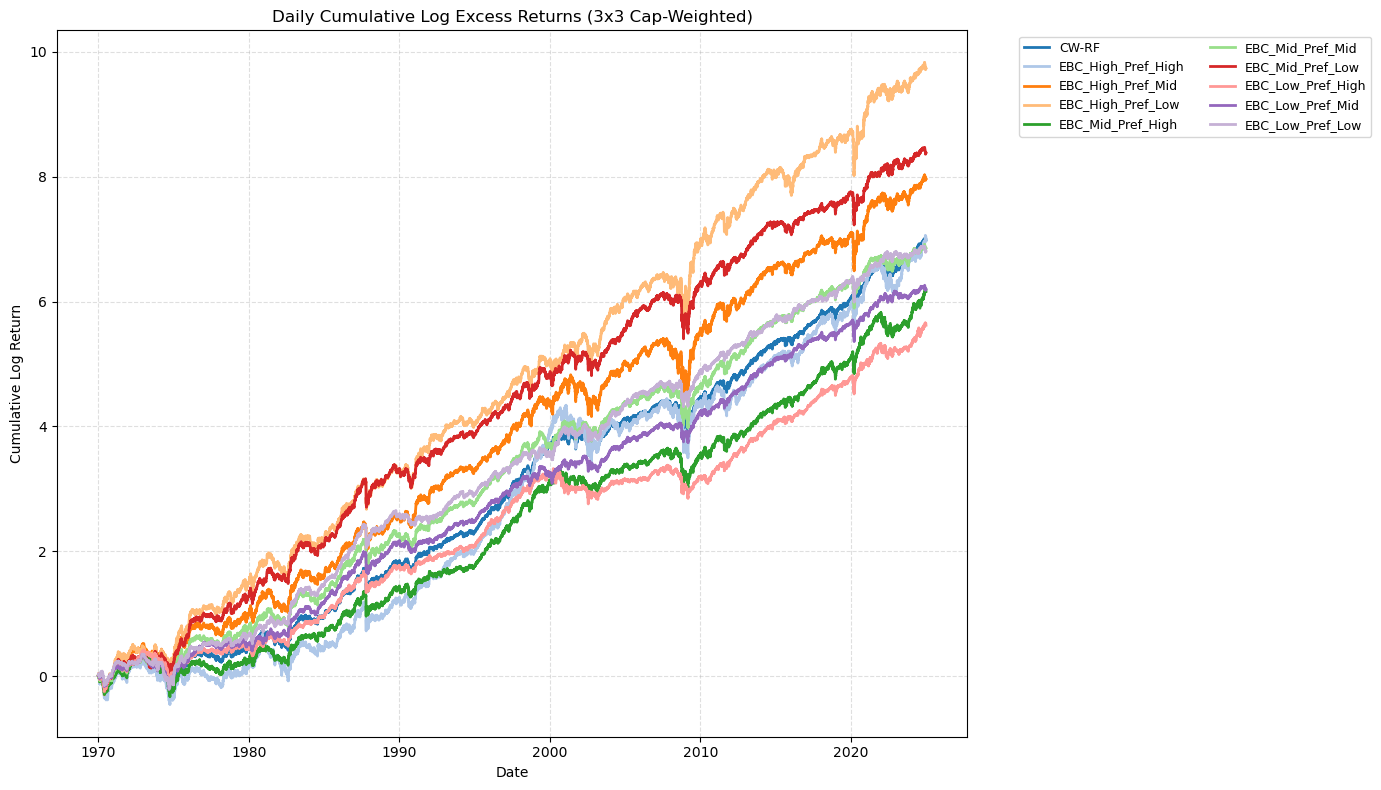

In [184]:
# ============================
# PLOTS
# ============================
plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Daily Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

In [186]:
results['pricing']

,mean_return,betaEBC,betaCap_EBC,alpha_ts,alpha_fm
portfolio,,,,,
Q1_Q1,0.000559,1.502833,1.422524,-0.000491,-2.627700e-06
Q1_Q2,0.000639,1.436451,0.248842,-0.000168,9.782606e-06
Q1_Q3,0.000689,1.466540,-0.448260,-0.000009,2.715684e-06
Q2_Q1,0.000487,1.056818,0.867306,-0.000228,1.038748e-06
Q2_Q2,0.000532,1.048146,0.037924,-0.000031,-1.156871e-05
Q2_Q3,0.000580,1.094836,-0.450345,0.000080,-1.001114e-05
Q3_Q1,0.000438,0.771161,0.486535,-0.000057,-9.942817e-07
Q3_Q2,0.000488,0.742513,-0.142439,0.000119,1.089132e-05
Q3_Q3,0.000509,0.752957,-0.535988,0.000205,7.734757e-07


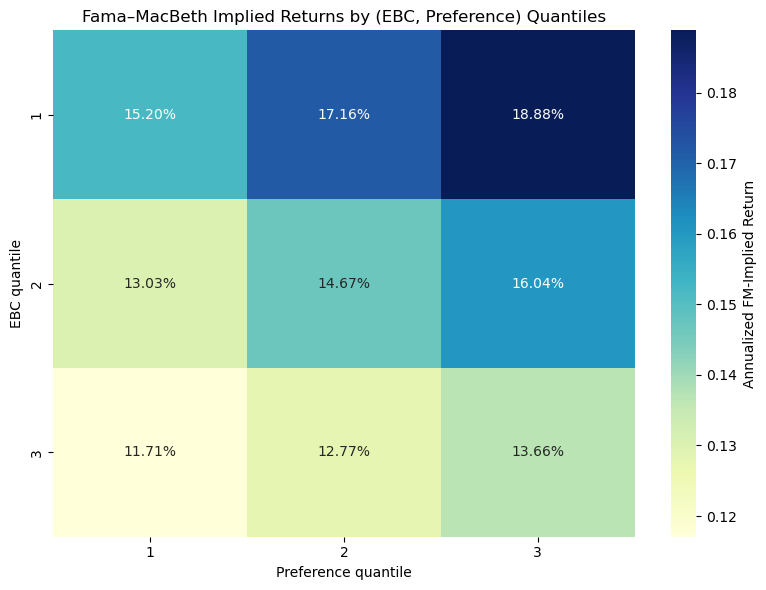

In [187]:
# FM expected-return grid (annualized %)
implied_returns = plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2,frequency='daily')

In [188]:
implied_returns_renamed = implied_returns

In [189]:
implied_returns_renamed = implied_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)


In [190]:
implied_returns_renamed

,High Preference,Medium Preference,Low Preference
High EBC,0.152009,0.171627,0.188813
Medium EBC,0.130270,0.146695,0.160389
Low EBC,0.117071,0.127736,0.136562


In [198]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
print(PROJECT_ROOT)
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "Ken"
implied_returns_renamed.to_csv(DATA_PROCESSED_DIR / "implied_returns_3x3_full_period.csv", index=True)


/Users/evi/Desktop/Invesco_Research_Project


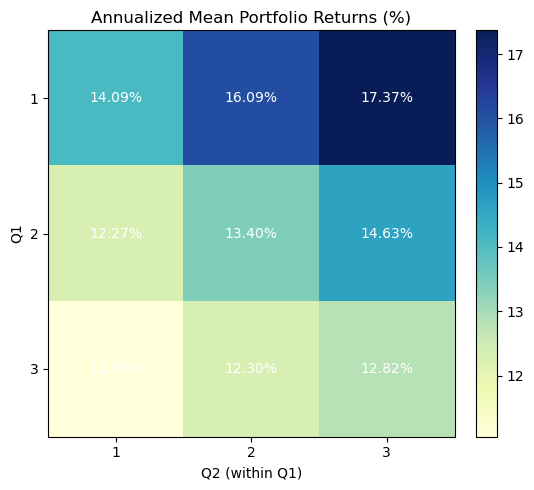

In [199]:
actual_returns = plots.plot_mean_grid(results["mean_grid"], annualize=True, frequency='daily')

In [200]:
actual_returns_renamed = actual_returns

In [201]:
actual_returns_renamed = actual_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)


In [202]:
actual_returns_renamed

,High Preference,Medium Preference,Low Preference
High EBC,14.088467,16.090859,17.369917
Medium EBC,12.274828,13.400606,14.627619
Low EBC,11.048383,12.298568,12.823542


In [203]:
actual_returns_renamed.to_csv(DATA_PROCESSED_DIR / "actual_returns_3x3_full_period.csv", index=True)

In [74]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [91]:
complete_df[selected_columns].rolling(252).corr()['CW-RF'].loc['1990-01-01':]

date                          
1990-01-02  CW-RF                 1.000000
            EBC_High_Pref_High    0.979914
            EBC_High_Pref_Mid     0.968865
            EBC_High_Pref_Low     0.940424
            EBC_Mid_Pref_High     0.985412
                                    ...   
2024-12-31  EBC_Mid_Pref_Mid      0.723898
            EBC_Mid_Pref_Low      0.450609
            EBC_Low_Pref_High     0.908450
            EBC_Low_Pref_Mid      0.407601
            EBC_Low_Pref_Low      0.182014
Name: CW-RF, Length: 88170, dtype: float64

In [104]:
temp_df = complete_df[selected_columns].rolling(252).corr().loc[:,'EBC_High_Pref_Low'].reset_index()

<Axes: xlabel='date'>

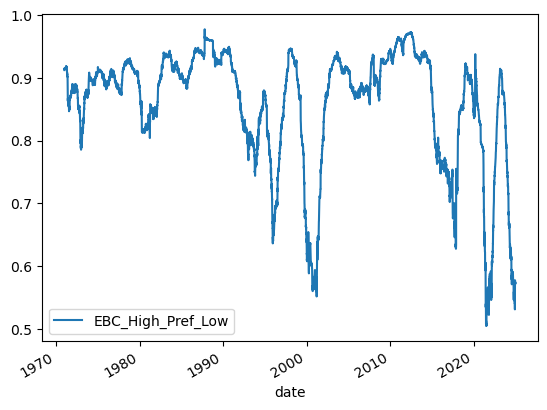

In [105]:
temp_df[temp_df['level_1']== 'CW-RF'].set_index('date').plot()

In [75]:
quantile_portfolios_returns.corr()

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
EBC_High_Pref_High,1.000000,0.886481,0.794620,0.875751,0.812185,0.743951,0.732603,0.660998,0.576113
EBC_High_Pref_Mid,0.886481,1.000000,0.929056,0.835882,0.911207,0.875156,0.731613,0.766066,0.707480
EBC_High_Pref_Low,0.794620,0.929056,1.000000,0.759787,0.895728,0.914308,0.672270,0.757392,0.732213
EBC_Mid_Pref_High,0.875751,0.835882,0.759787,1.000000,0.856199,0.754561,0.886123,0.743965,0.631207
EBC_Mid_Pref_Mid,0.812185,0.911207,0.895728,0.856199,1.000000,0.920772,0.803082,0.862546,0.788484
EBC_Mid_Pref_Low,0.743951,0.875156,0.914308,0.754561,0.920772,1.000000,0.708024,0.840941,0.824076
EBC_Low_Pref_High,0.732603,0.731613,0.672270,0.886123,0.803082,0.708024,1.000000,0.796050,0.668060
EBC_Low_Pref_Mid,0.660998,0.766066,0.757392,0.743965,0.862546,0.840941,0.796050,1.000000,0.877919
EBC_Low_Pref_Low,0.576113,0.707480,0.732213,0.631207,0.788484,0.824076,0.668060,0.877919,1.000000


In [56]:
quantile_portfolios_returns.index.name = "date"

In [57]:
quantile_portfolios_returns.to_csv(DATA_PROCESSED_DIR / "daily_quantile_returns_3x3.csv")

## Fitted GARCH

In [110]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt


In [111]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [125]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'CW-EW', 'CW-EBC', 'MKT_RF', 'SMB', 'HML', 'RMW',
       'CMA', 'RF', 'MOM', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low', 'CW-RF'],
      dtype='object')

In [126]:
portfolio_name = 'CW-RF'

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        CW-RF   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -17801.4
Distribution:      Standardized Student's t   AIC:                           35612.7
Method:                  Maximum Likelihood   BIC:                           35650.4
                                              No. Observations:                13871
Date:                      Wed, Feb 11 2026   Df Residuals:                    13870
Time:                              09:39:03   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

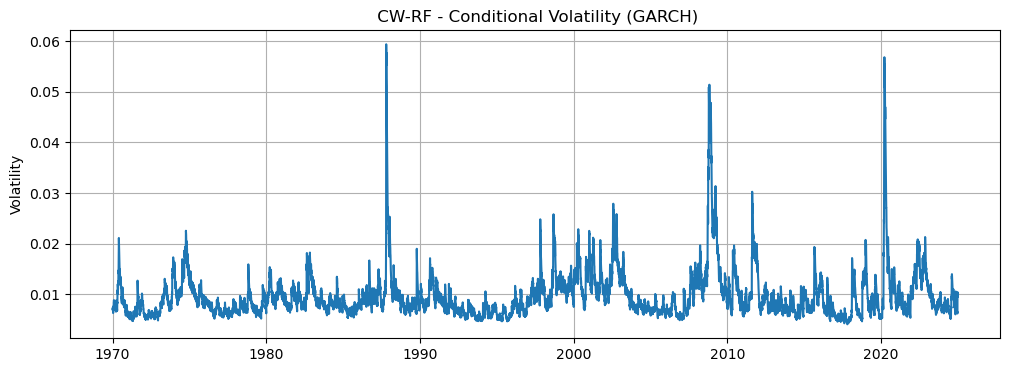

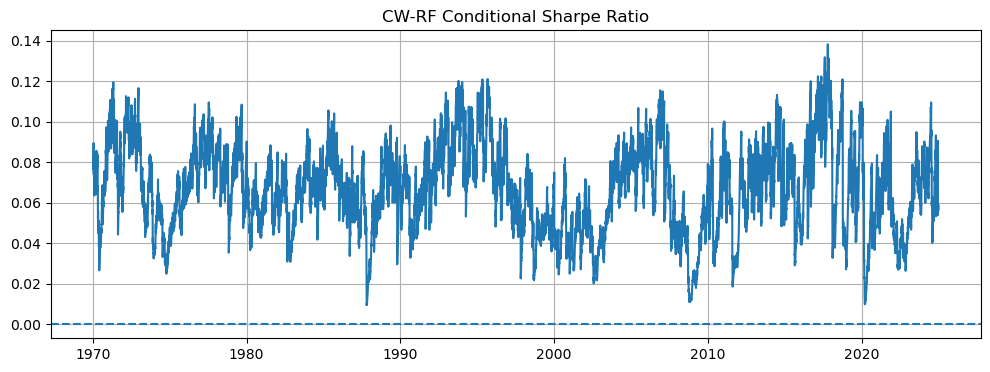

In [124]:
portfolio = complete_df[portfolio_name]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()





                        Constant Mean - GARCH Model Results                         
Dep. Variable:            EBC_High_Pref_Low   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -21931.5
Distribution:      Standardized Student's t   AIC:                           43873.1
Method:                  Maximum Likelihood   BIC:                           43910.8
                                              No. Observations:                13871
Date:                      Wed, Feb 11 2026   Df Residuals:                    13870
Time:                              09:16:57   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

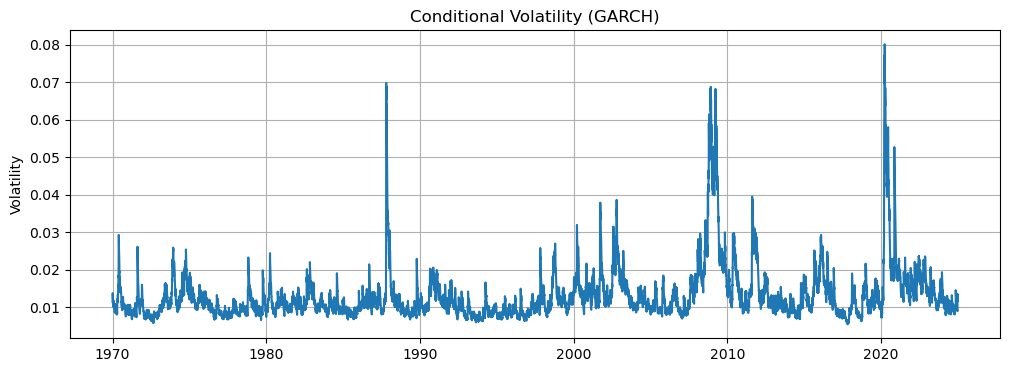

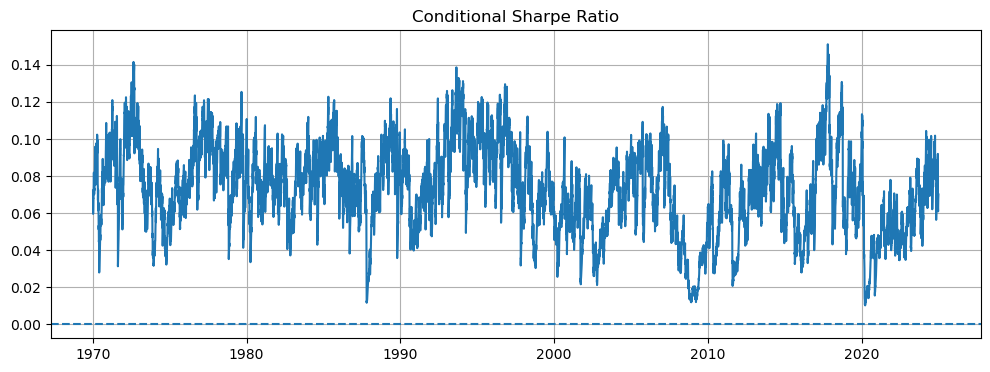

In [118]:
portfolio = complete_df["EBC_High_Pref_Low"]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title("Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title("Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



